In [1]:
%load_ext autoreload
%autoreload 2
# %env CUDA_VISIBLE_DEVICES=0

## Prelims

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


In [ ]:
split_id = 11042026
pd.set_option('display.max_rows', None)

log_dir = 'log_dir'
CLEANED_FILE= 'areds_cleaned'


In [ ]:

df2 = pd.read_csv(os.path.join(log_dir, f"{CLEANED_FILE}.csv"))


In [19]:
def make_families(x):
    family= None
    if (x =='simclr_nako') or (x == 'simclr_inet_nako') or (x=='nako_mae') or (x=='nako_mae_scr'):
        family = 'SSL'
    elif (x=='dino_meta') or (x=='dino_nako') or (x=='retfound'):
        family = 'FM'
    elif (x=='scratch') or (x=='resnet_imagenet'):
        family = 'Sup.'
    else:
        raise ValueError('Unknown')
    return family

In [20]:
df2['model_family'] = df2['summary'].apply(lambda x: make_families(x) )
df2['model_family'].value_counts(dropna = False)

model_family
SSL     560
FM      420
Sup.    280
Name: count, dtype: int64

In [22]:
dino_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_nako") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_nako_mlp_fef.shape, dino_nako_mlp_fet.shape, dino_nako_lin_fef.shape, dino_nako_lin_fet.shape

((35, 83), (35, 83), (35, 83), (35, 83))

In [24]:
dino_meta_lin_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_lin_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "dino_meta")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
dino_meta_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "dino_meta")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
dino_meta_mlp_fef.shape, dino_meta_mlp_fet.shape, dino_meta_lin_fef.shape, dino_meta_lin_fet.shape


((35, 83), (35, 83), (35, 83), (35, 83))

In [26]:
simclr_inet_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_inet_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_inet_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_inet_nako_lin_fef.shape, simclr_inet_nako_lin_fet.shape, simclr_inet_nako_mlp_fef.shape, simclr_inet_nako_mlp_fet.shape


((35, 83), (35, 83), (35, 83), (35, 83))

In [28]:
simclr_nako_lin_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_lin_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
simclr_nako_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "simclr_nako")   & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
simclr_nako_mlp_fef.shape, simclr_nako_mlp_fet.shape, simclr_nako_lin_fef.shape, simclr_nako_lin_fet.shape


((35, 83), (35, 83), (35, 83), (35, 83))

In [30]:
imagenet_resnet_lin_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_lin_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
imagenet_resnet_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "resnet_imagenet")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
imagenet_resnet_mlp_fef.shape, imagenet_resnet_mlp_fet.shape, imagenet_resnet_lin_fef.shape, imagenet_resnet_lin_fet.shape


((35, 83), (35, 83), (35, 83), (35, 83))

In [32]:
resnet_scratch_lin_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_lin_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "scratch") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
resnet_scratch_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "scratch")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
resnet_scratch_mlp_fef.shape, resnet_scratch_mlp_fet.shape, resnet_scratch_lin_fef.shape, resnet_scratch_lin_fet.shape

((35, 83), (35, 83), (35, 83), (35, 83))

In [34]:
retfound_lin_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_lin_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
retfound_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "retfound") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
retfound_mlp_fef.shape, retfound_mlp_fet.shape, retfound_lin_fef.shape, retfound_lin_fet.shape

((35, 83), (35, 83), (35, 83), (35, 83))

In [36]:
nako_mae_lin_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_lin_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_mlp_fef.shape, nako_mae_mlp_fet.shape, nako_mae_lin_fef.shape, nako_mae_lin_fet.shape

((35, 83), (35, 83), (35, 83), (35, 83))

In [37]:
nako_mae_scr_lin_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae_scr") & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_scr_lin_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae_scr")  & (df2['survival_head']  == "linear") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_scr_mlp_fef = pd.DataFrame(df2[(df2['summary']  == "nako_mae_scr") & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 0) ]).reset_index(drop=True)
nako_mae_scr_mlp_fet = pd.DataFrame(df2[(df2['summary']  == "nako_mae_scr")  & (df2['survival_head']  == "mlp") & (df2['freeze_encoder']  == 1) ]).reset_index(drop=True)
nako_mae_scr_mlp_fef.shape, nako_mae_scr_mlp_fet.shape, nako_mae_scr_lin_fef.shape, nako_mae_scr_lin_fet.shape

((35, 83), (35, 83), (35, 83), (35, 83))

In [39]:
df_summarize = df2.copy()
df_summarize.rename(columns={'test/ibs':'ibs', 'test/concordance_index': 'cindex'}, inplace = True)

In [40]:
df_summarize =df_summarize[['Name',	'summary',	'survival_head',	'train_size',	'freeze_encoder',	'ibs'	,'cindex',	'seed']]
df_summarize.head()

,Name,summary,survival_head,train_size,freeze_encoder,ibs,cindex,seed
0,testrun_False_FE_False_100_linear_2026-06-15_1...,simclr_inet_nako,linear,100.0,0,0.083749,0.754239,830186
1,testrun_False_FE_False_100_linear_2026-06-15_1...,simclr_inet_nako,linear,100.0,0,0.077905,0.801834,822356
2,testrun_False_FE_False_20000_linear_2026-06-15...,dino_nako,linear,20000.0,0,0.059460,0.902461,479461
3,testrun_False_FE_False_100_linear_2026-06-15_1...,simclr_nako,linear,100.0,0,0.080244,0.825624,109433
4,testrun_False_FE_False_100_mlp_2026-06-15_11-3...,dino_nako,mlp,100.0,0,0.089334,0.534345,164150


In [41]:
print(df_summarize.shape)

(1260, 8)


In [42]:
df_summarize['summary'].value_counts()

summary
simclr_inet_nako    140
dino_nako           140
simclr_nako         140
resnet_imagenet     140
retfound            140
dino_meta           140
scratch             140
nako_mae            140
nako_mae_scr        140
Name: count, dtype: int64

In [48]:
all_plots = {
   
    "retfound_lin_fef":retfound_lin_fef,
    "retfound_lin_fet":retfound_lin_fet,

    "resnet_scratch_lin_fef": resnet_scratch_lin_fef,
    "resnet_scratch_lin_fet": resnet_scratch_lin_fet,
 
    "retfound_mlp_fef":retfound_mlp_fef,
    "retfound_mlp_fet":retfound_mlp_fet,

    "resnet_scratch_mlp_fef": resnet_scratch_mlp_fef,
    "resnet_scratch_mlp_fet": resnet_scratch_mlp_fet,

    "resnet_INet_lin_fef": imagenet_resnet_lin_fef,
    "resnet_INet_lin_fet": imagenet_resnet_lin_fet,

    "resnet_INet_mlp_fef": imagenet_resnet_mlp_fef,
    "resnet_INet_mlp_fet": imagenet_resnet_mlp_fet,

    "nako_mae_lin_fef": nako_mae_lin_fef,
    "nako_mae_lin_fet": nako_mae_lin_fet,

    "nako_mae_mlp_fef": nako_mae_mlp_fef,
    "nako_mae_mlp_fet": nako_mae_mlp_fet,

    "nako_mae_scr_lin_fef": nako_mae_scr_lin_fef,
    "nako_mae_scr_lin_fet": nako_mae_scr_lin_fet,

    "nako_mae_scr_mlp_fef": nako_mae_scr_mlp_fef,
    "nako_mae_scr_mlp_fet": nako_mae_scr_mlp_fet,

    "simclr_nako_lin_fef": simclr_nako_lin_fef,
    "simclr_nako_lin_fet": simclr_nako_lin_fet,

    "simclr_nako_mlp_fef": simclr_nako_mlp_fef,
    "simclr_nako_mlp_fet": simclr_nako_mlp_fet,

    "simclr_INet_nako_lin_fef": simclr_inet_nako_lin_fef,
    "simclr_INet_nako_lin_fet": simclr_inet_nako_lin_fet,

    "simclr_INet_nako_mlp_fef": simclr_inet_nako_mlp_fef,
    "simclr_INet_nako_mlp_fet": simclr_inet_nako_mlp_fet,

    "dino_nako_lin_fef": dino_nako_lin_fef,
    "dino_nako_lin_fet": dino_nako_lin_fet,

    "dino_nako_mlp_fef": dino_nako_mlp_fef,
    "dino_nako_mlp_fet": dino_nako_mlp_fet,

    "dino_meta_lin_fef": dino_meta_lin_fef,
    "dino_meta_lin_fet": dino_meta_lin_fet,

    "dino_meta_mlp_fef": dino_meta_mlp_fef,
    "dino_meta_mlp_fet": dino_meta_mlp_fet,
    }


In [ ]:
from all_utils import plot_finetuning_strategies_all

In [ ]:
save_path = './figures'
stylefile = 'mpl.mplstyle'
os.makedirs(save_path, exist_ok=True)

In [ ]:
y_ticks_list1 = [0.05, 0.08, 0.11]   
y_ticks_list2 = [0.50,  0.75,  1.0]   
axis_br_size=0.01
axis_br_gap=0.018
axis_br_y_pos=-0.03     
axis_br_x_pos=-0.01 

In [ ]:
fet_plots = all_plots.copy()
fet_keys_to_delete = [key for key in fet_plots if 'fef' in key]
for key in fet_keys_to_delete:
    del fet_plots[key]
fef_plots = all_plots.copy()
fef_keys_to_delete = [key for key in fef_plots if 'fet' in key]
for key in fef_keys_to_delete:
    del fef_plots[key]

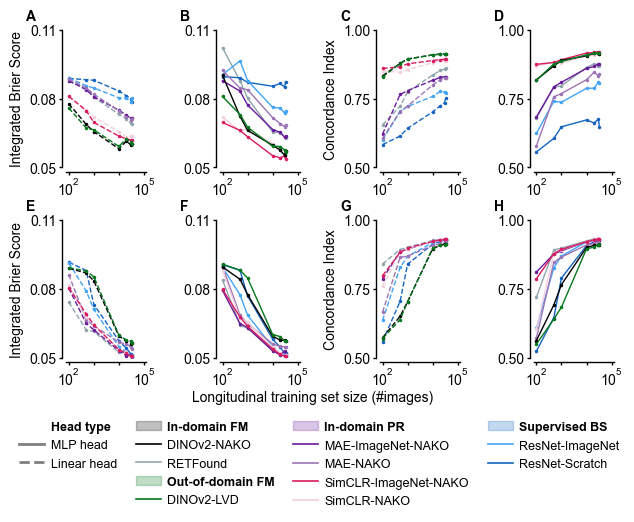

(<Figure size 624.049x520 with 8 Axes>,
 array([[<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
         <Axes: ylabel='Concordance Index'>, <Axes: >],
        [<Axes: ylabel='Integrated Brier Score'>, <Axes: >,
         <Axes: ylabel='Concordance Index'>, <Axes: >]], dtype=object))

In [63]:
plot_finetuning_strategies_all([fet_plots, fef_plots], show_count=False,
                        more_suptitle = 'Freezing Encoder', 
                        save_path = os.path.join(save_path, '_00_freeze_finetune'), 
                        to_plot = 'mlp',
                        stylef = stylefile, 
                        num_y_ticks = 2,  
                        axis_br_size=axis_br_size,
                        axis_br_gap=axis_br_gap,
                        axis_br_y_pos=axis_br_y_pos,      
                        axis_br_x_pos=axis_br_x_pos,  
                        y_ticks_list1=y_ticks_list1,
                        y_ticks_list2=y_ticks_list2,
                        define_ticks=True,
                        text_y=1.15,
                        text_x=-0.5,
                        tick_length = 2,
                        # tick_width = 1,
                        fontsize = 10,
                        remove_mae_scr=False


)